# Proyek Analisis Data: [e-commece dataset]
- **Nama:** Ammara Desma M
- **Email:** m179b4kx0468@bangkit.academy
- **ID Dicoding:** Ammara Marzooqa

## Menentukan Pertanyaan Bisnis

- Berapa massa dari produk yang paling berat?

- Berada di kota manakah yang terdapat seller terbanyak?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
sellers_df = pd.read_csv("sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Pada dataset seller terdapat 5 data awal yang terlihat banyak sekali seller yang menghuni di state SP
- Pada dataset produk terdapat 5 data awal yang terlihat bahwa untuk product_name_category "esporte_lazer" memiliki product_name_length terpanjang yaitu 46.0

### Assessing Data

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- Pada dataset product,terdapat 8 atribut yang memiliki missing value
- Untuk dataset seller tidak perlu dilakukan cleaning karena tidak ditemukan duplikat data dan missing value

### Cleaning Data

In [ ]:
products_df.product_category_name.value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [ ]:
print(products_df.dtypes)

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


In [ ]:
products_df["product_name_lenght"].fillna(value = products_df["product_name_lenght"].mean(), inplace=True)

<ipython-input-14-4921ac6e7ea0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_name_lenght"].fillna(value = products_df["product_name_lenght"].mean(), inplace=True)


In [ ]:
most_common_category = products_df["product_category_name"].mode()[0]

In [ ]:
products_df["product_category_name"].fillna(value=most_common_category, inplace=True)

<ipython-input-16-07f1bb432cf7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna(value=most_common_category, inplace=True)


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.150458,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products_df["product_weight_g"].fillna(value = products_df["product_weight_g"].mean(), inplace=True)

<ipython-input-19-136bb1ee91f6>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_weight_g"].fillna(value = products_df["product_weight_g"].mean(), inplace=True)


In [ ]:
products_df["product_length_cm"].fillna(value = products_df["product_length_cm"].mean(), inplace=True)

<ipython-input-20-2886b2987229>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_length_cm"].fillna(value = products_df["product_length_cm"].mean(), inplace=True)


In [ ]:
products_df["product_height_cm"].fillna(value = products_df["product_height_cm"].mean(), inplace=True)

<ipython-input-21-483e37b2f29d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_height_cm"].fillna(value = products_df["product_height_cm"].mean(), inplace=True)


In [ ]:
products_df["product_width_cm"].fillna(value = products_df["product_width_cm"].mean(), inplace=True)

<ipython-input-22-f7974ce3f33c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_width_cm"].fillna(value = products_df["product_width_cm"].mean(), inplace=True)


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,610
product_photos_qty,610
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [ ]:
products_df.dropna(axis=0, inplace=True)

In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- Pada dataset produk dengan atribut product_category_name terdapat missing 610, sehingga saya fill the missing value with mode
- product_weight_g, product_length_cm, product_height_cm, product_width_cm, saya mengisikan value missing dengan mean
- Pada dataset seller tidak terdapat missing value dan duplikasi data



## Exploratory Data Analysis (EDA)

### Explore Data Sellers dan Products

In [ ]:
sellers_df.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


In [ ]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341,32341,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000,32341.000000
unique,32341,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.956571,30.854544,16.958812,23.208596
std,NaN,NaN,10.245741,635.115225,1.736766,4279.225683,16.955703,13.635904,12.078575
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [ ]:
products_df.groupby(by="product_weight_g").product_id.nunique().sort_values(ascending=False)

,product_id
product_weight_g,
200.000000,1985
300.000000,1528
150.000000,1243
400.000000,1175
100.000000,1173
...,...
2276.472488,1
2245.000000,1
2243.000000,1


In [ ]:
sellers_df.groupby(by="seller_city")['seller_id'].count().sort_values(ascending=False)

,seller_id
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
ivoti,1
itirapina,1
itau de minas,1


In [ ]:
sellers_df.groupby(by="seller_city")['seller_state'].count().sort_values(ascending=False)

,seller_state
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
ivoti,1
itirapina,1
itau de minas,1


**Insight:**
- Terlihat bahwa di state maupun city untuk seller terbanyak yaitu ada di San Paulo
- Untuk produk terberat yaitu ada di angka 40425.000000

## Visualization & Explanatory Analysis

### Pertanyaan 1:

<ipython-input-31-85089df1ff01>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tup

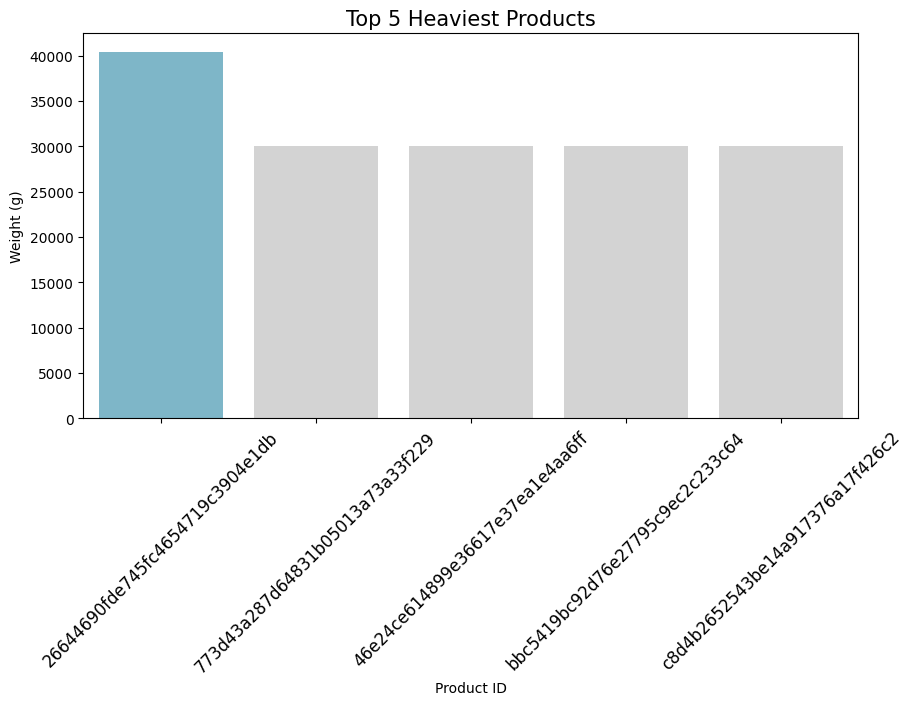

In [ ]:
all_df = pd.read_csv("products_dataset.csv")
# Mengelompokkan data berdasarkan produk dan menghitung berat produk
byweight_df = all_df.groupby(by="product_id").agg({
    "product_weight_g": "max"  # Mengambil berat maksimum untuk setiap produk
}).reset_index()

# Mengurutkan produk dari berat terbesar hingga terkecil
byweight_df = byweight_df.sort_values(by="product_weight_g", ascending=False)

# Pilih beberapa produk terberat untuk ditampilkan dalam grafik
top_heavy_products = byweight_df.head(5)  # Mengambil 5 produk terberat

# Membuat plot
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    y="product_weight_g",
    x="product_id",
    data=top_heavy_products,
    palette=colors_
)

plt.title("Top 5 Heaviest Products", loc="center", fontsize=15)
plt.ylabel("Weight (g)")
plt.xlabel("Product ID")
plt.tick_params(axis='x', labelsize=12)
plt.xticks(rotation=45)
plt.show()


### Pertanyaan 2:

<ipython-input-32-942130d0cbc8>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tup

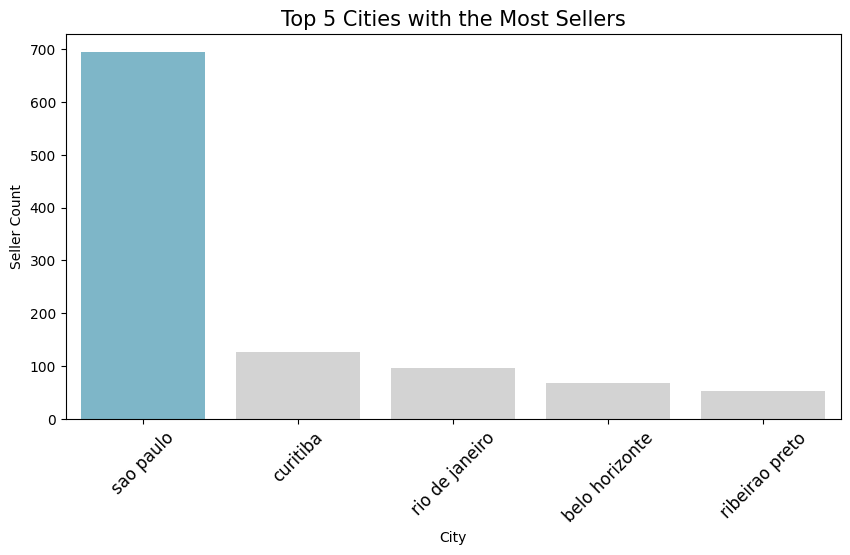

In [ ]:
# Asumsikan data penjual ada di dataset dan telah dimuat ke dalam DataFrame
all_df = pd.read_csv("sellers_dataset.csv")

# Mengelompokkan data berdasarkan kota dan menghitung jumlah penjual unik
byseller_city_df = all_df.groupby(by="seller_city").seller_id.nunique().reset_index()

# Mengubah nama kolom untuk memudahkan pembacaan
byseller_city_df.rename(columns={
    "seller_id": "seller_count"
}, inplace=True)

# Mengurutkan kota berdasarkan jumlah penjual dari yang terbanyak
byseller_city_df = byseller_city_df.sort_values(by="seller_count", ascending=False)

# Pilih beberapa kota dengan penjual terbanyak untuk ditampilkan dalam grafik
top_seller_cities = byseller_city_df.head(5)  # Mengambil 5 kota dengan penjual terbanyak

# Membuat plot
plt.figure(figsize=(10, 5))
colors_ = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    y="seller_count",
    x="seller_city",
    data=top_seller_cities,
    palette=colors_
)

plt.title("Top 5 Cities with the Most Sellers", loc="center", fontsize=15)
plt.ylabel("Seller Count")
plt.xlabel("City")
plt.tick_params(axis='x', labelsize=12)
plt.xticks(rotation=45)  # Rotasi label sumbu x agar terlihat lebih jelas
plt.show()


**Insight:**
- Dapat dilihat bahwa seller dengan jumlah terbanyak berada di San Paulo
- Untuk data berat produk, dapat dilihat bahwa produk terberat yaitu ada di angka 40000 g

## Conclusion

- Terlihat bahwa produk paling berat yaitu berada di 40000-an g
- Kota dengan seller terbanyak yaitu berada di San Paulo dengan state SP

In [ ]:
all_df.to_csv("all_data.csv", index=False)